In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold, ParameterGrid, HalvingGridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, classification_report, roc_auc_score, make_scorer, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib


In [142]:
cars = pd.read_csv('../datasets/ml_410k.csv')

In [143]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 413290 entries, 0 to 413289
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   brand               413290 non-null  str    
 1   name                413290 non-null  str    
 2   bodyType            413290 non-null  str    
 3   color               413290 non-null  str    
 4   fuelType            413290 non-null  str    
 5   year                413290 non-null  int64  
 6   mileage             413290 non-null  float64
 7   transmission        413290 non-null  str    
 8   power               413290 non-null  float64
 9   price               413290 non-null  int64  
 10  engineDisplacement  413290 non-null  float64
 11  location            413290 non-null  str    
dtypes: float64(3), int64(2), str(7)
memory usage: 37.8 MB


In [144]:
cars['brand'].unique()

<StringArray>
[          'BMW', 'Mercedes-Benz',           'ГАЗ',        'Toyota',
        'Nissan',          'Лада',       'Москвич',            'ИЖ',
          'Audi',         'Mazda',    'Mitsubishi',          'Ford',
         'Honda',    'Volkswagen',         'Isuzu',     'SsangYong',
       'Peugeot',        'Subaru',         'Volvo',       'Citroen',
          'Opel',           'УАЗ',           'Kia',       'Porsche',
       'Hyundai',        'Daewoo',      'Daihatsu',           'ЗАЗ',
        'Suzuki',         'Dodge',          'Jeep',       'Renault',
      'Chrysler',     'Chevrolet',    'Land Rover',         'Lexus',
      'Cadillac',          'Fiat',      'Infiniti',         'Skoda',
        'Jaguar',          'MINI',    'Great Wall',         'Chery',
           'JAC',         'Lifan',         'Geely',           'FAW',
        'Vortex',        'Datsun',       'Changan',      'Dongfeng',
         'Haval',       'Genesis',         'EXEED',          'Tank',
         'OMODA',   

In [145]:
columns = [
    'name', 
    'brand', 
    'bodyType', 
    'fuelType', 
    'transmission', 
    'location'
]
cars_freq = cars.copy()
# for column in columns:
#         vc = cars_freq[column].value_counts(normalize=True, dropna=False)
#         mapping = vc.to_dict()
#         cars_freq[column + '_freq'] = cars_freq[column].map(mapping)

In [146]:
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
cars['body_ord'] = enc.fit_transform(cars[['bodyType']])
cars['fuel_ord'] = enc.fit_transform(cars[['fuelType']]) # Not
cars['name_ord'] = enc.fit_transform(cars[['name']])
cars['brand_ord'] = enc.fit_transform(cars[['brand']]) # Not
cars['transmission_ord'] = enc.fit_transform(cars[['transmission']])
cars['location_ord'] = enc.fit_transform(cars[['location']]) # Not
cars['color_ord'] = enc.fit_transform(cars[['color']]) # Not


In [147]:
import joblib

cat_cols = ['bodyType', 'fuelType', 'name', 'brand', 'transmission', 'location', 'color']

mappings = {}
for c in cat_cols:
    # приводим к строкам, чтобы None/NaN были тоже ключами, если нужно
    cats = cars[c].astype(str).unique().tolist()
    mappings[c] = {cat: i for i, cat in enumerate(cats)}
    # если хотите, можно оставить порядок, который давал OrdinalEncoder

joblib.dump(mappings, 'ord_mappings.joblib')

['ord_mappings.joblib']

In [148]:
cars = cars.drop(columns=['engineDisplacement', 'name', 'brand', 'bodyType', 'fuelType', 'transmission', 'location', 'color'])

In [149]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 413290 entries, 0 to 413289
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              413290 non-null  int64  
 1   mileage           413290 non-null  float64
 2   power             413290 non-null  float64
 3   price             413290 non-null  int64  
 4   body_ord          413290 non-null  float64
 5   fuel_ord          413290 non-null  float64
 6   name_ord          413290 non-null  float64
 7   brand_ord         413290 non-null  float64
 8   transmission_ord  413290 non-null  float64
 9   location_ord      413290 non-null  float64
 10  color_ord         413290 non-null  float64
dtypes: float64(9), int64(2)
memory usage: 34.7 MB


In [150]:
# cars = cars[cars['price'] < 2000000]

In [151]:
lower = cars['price'].quantile(0.1)
upper = cars['price'].quantile(0.9)
cars['price'] = cars['price'].clip(lower, upper)
# cars = cars[cars['price'] > lower]
# cars = cars[cars['price'] < upper]

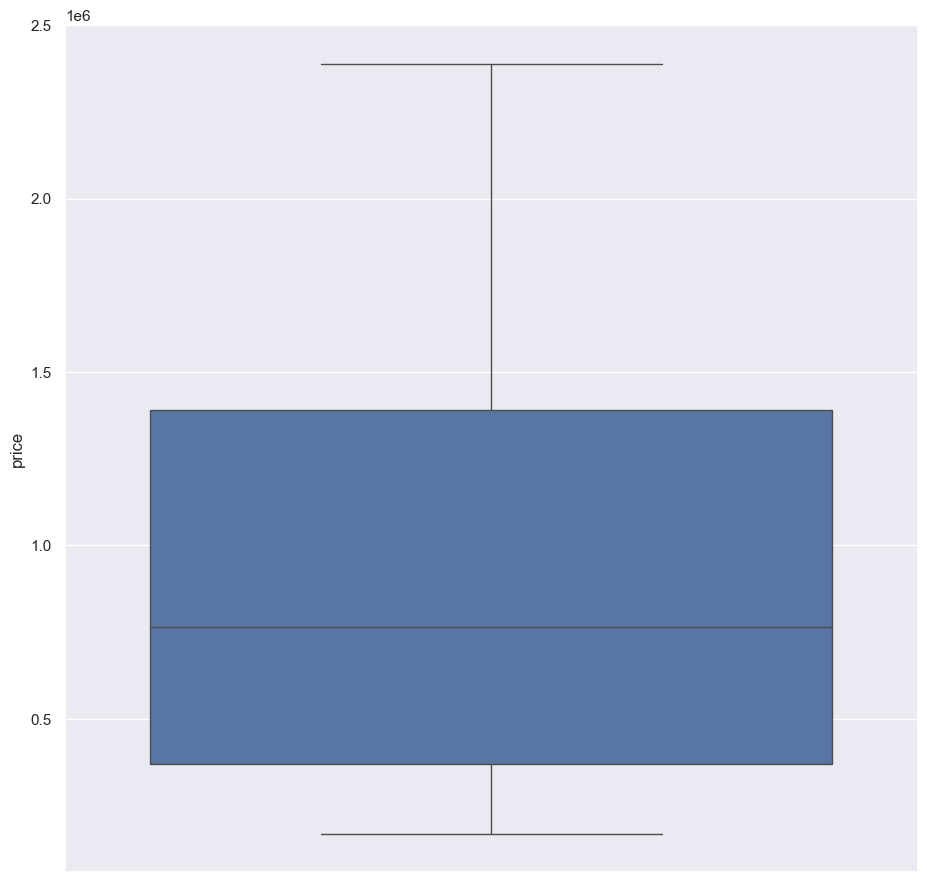

In [152]:
sns.boxplot(cars['price'])
plt.show()

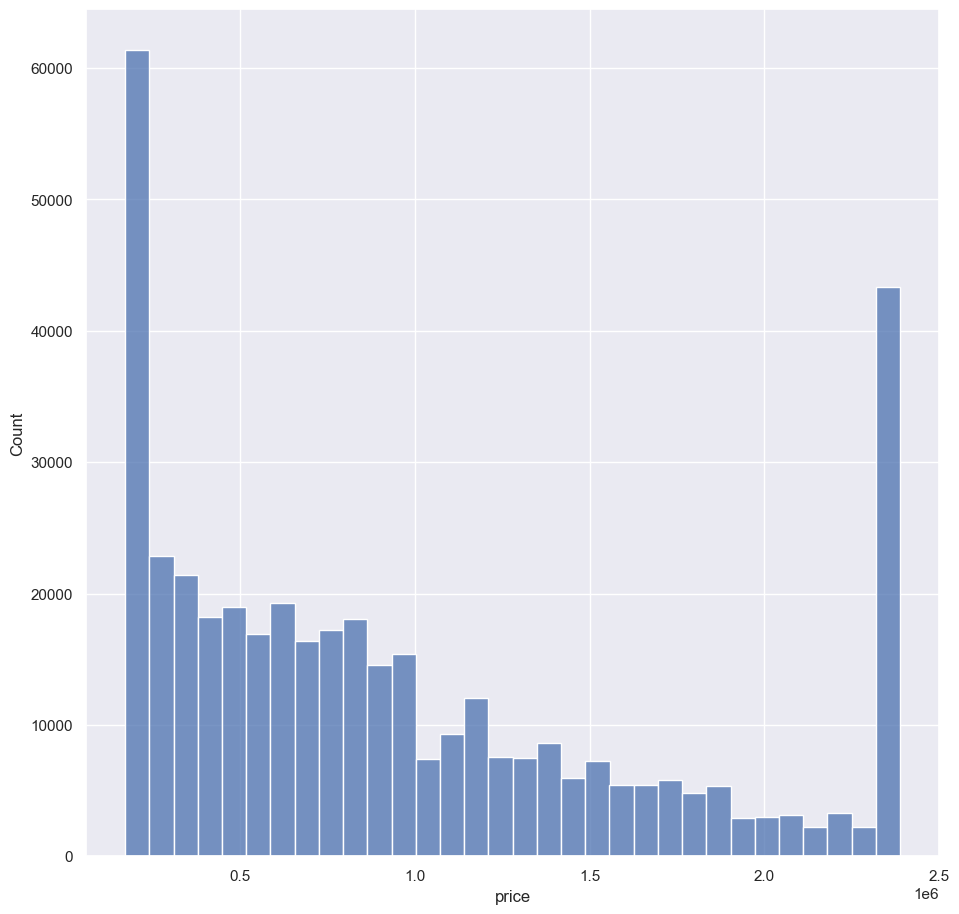

In [153]:
sns.histplot(cars['price'], bins=32)
plt.show()

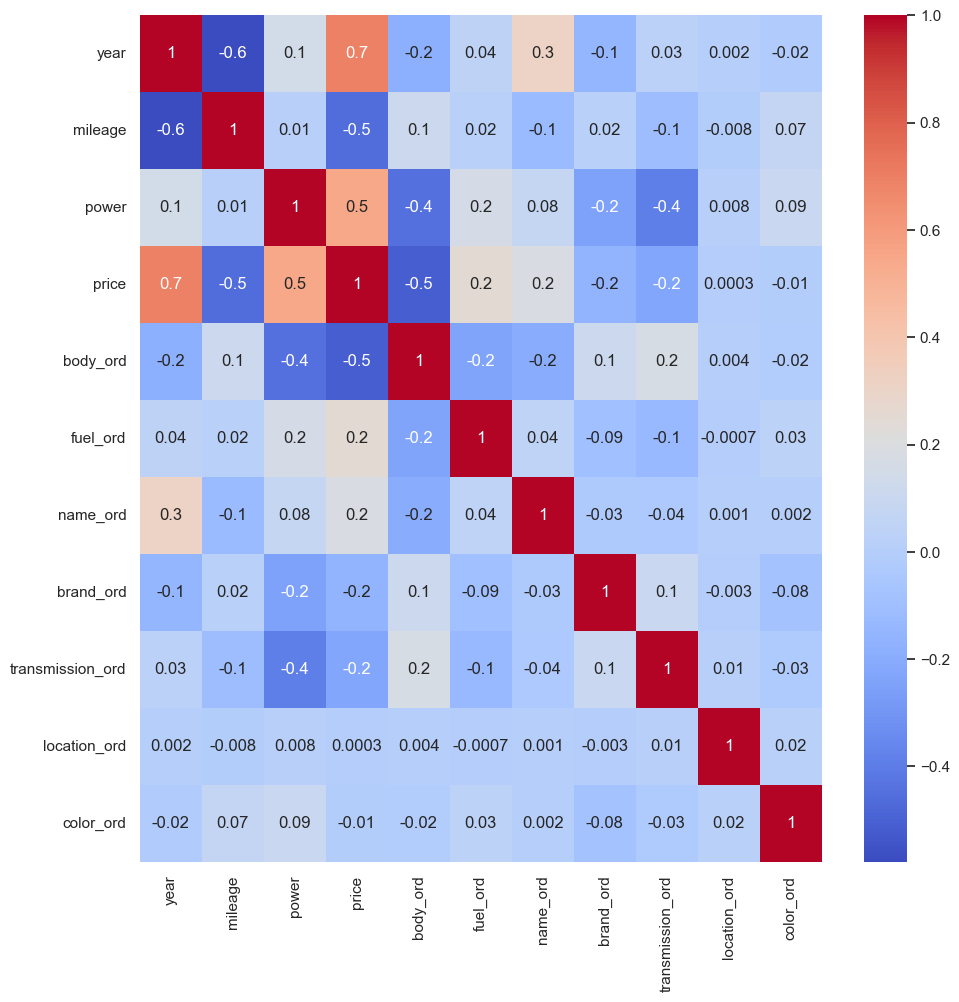

In [154]:
sns.set_theme(rc={'figure.figsize': (11, 11)})
sns.heatmap(cars.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.1g')
plt.show()

In [155]:
X = cars.drop(columns=['price'])
y = cars['price']

scaler = StandardScaler()
X = scaler.fit_transform(X)
joblib.dump(scaler, 'scaler.joblib')



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=12,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=0.05,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:679254.11287
[100]	validation_0-rmse:125262.15598
[200]	validation_0-rmse:120841.10696
[299]	validation_0-rmse:119130.98640


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [156]:
param_grid = {
    'n_estimators': [300, 500, 700],
    'max_depth': [5, 10, 12],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'reg_alpha': [0.01, 0.05, 0.1],
    'reg_lambda': [0.01, 0.05, 0.1]
}

model_obj = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

try:
    scoring = 'neg_root_mean_squared_error'
except Exception:
    from sklearn.metrics import mean_squared_error
    scoring = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))

# model = HalvingGridSearchCV(
#     estimator=model_obj,
#     param_grid=param_grid,
#     scoring=scoring,
#     cv=5,                # 3-fold CV (можно увеличить до 5)
#     n_jobs=-1,
#     verbose=1,
#     refit=True
# )

# total_tasks = len(list(ParameterGrid(param_grid))) * 3
# with tqdm_joblib(tqdm(desc="GridSearchCV", total=total_tasks)) as progress_bar:
#     model.fit(X_train, y_train)


# best_params = model.best_params_
# best_score = model.best_score_
# print("Best params:", best_params)
# print("Best CV RMSE (approx):", best_score)

In [157]:
y_pred = model.predict(X_test)  # TransformedTargetRegressor вернёт предсказание в исходной шкале (expm1)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse_test:.2f}, MAE: {mae_test:.2f}, R2: {r2_test:.4f}")

Test RMSE: 119130.99, MAE: 72966.73, R2: 0.9718


In [158]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 413290 entries, 0 to 413289
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              413290 non-null  int64  
 1   mileage           413290 non-null  float64
 2   power             413290 non-null  float64
 3   price             413290 non-null  float64
 4   body_ord          413290 non-null  float64
 5   fuel_ord          413290 non-null  float64
 6   name_ord          413290 non-null  float64
 7   brand_ord         413290 non-null  float64
 8   transmission_ord  413290 non-null  float64
 9   location_ord      413290 non-null  float64
 10  color_ord         413290 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 34.7 MB


In [159]:
import joblib


joblib.dump(model, 'xgb_regressor.joblib')

['xgb_regressor.joblib']

In [160]:
required_columns = [
        "year", 
        "mileage", 
        "power", 
        "bodyType_ord", 
        "fuelType_ord", 
        "name_ord", 
        "brand_ord",
        "transmission_ord", 
        "location_ord", 
        "color_ord"
    ]

df = pd.DataFrame([{
            'year': 2009,
            'power': 102,
            'mileage': 230000,
            'bodyType': 'Хэтчбек 5 дв.',
            'fuelType': 'Бензин',
            'name': 'Golf',
            'brand': 'Volkswagen',
            'transmission': 'Робот',
            'location': 'Михайловск',
            'color': 'Красный'
        }])

cat_cols = ['bodyType', 'fuelType', 'name', 'brand', 'transmission', 'location', 'color']

# применяем маппинги; unknown -> -1
for c in cat_cols:
    map_dict = mappings.get(c, {})
    # приводим к str, чтобы совпадение с тем, как вы строили mappings
    df[c + '_ord'] = df[c].astype(str).map(map_dict).astype(int)

X = df[required_columns].astype(float).values

scaler = StandardScaler()
X = scaler.fit_transform(X)

result = model.predict(X)
result

array([906262.75], dtype=float32)